Epoch 0 Loss 0.11376694589853287
Epoch 300 Loss 0.025380095466971397
Epoch 600 Loss 0.021708112210035324
Epoch 900 Loss 0.018410788848996162
Epoch 1200 Loss 0.016904717311263084
Epoch 1500 Loss 0.016059430316090584
Epoch 1800 Loss 0.01470968034118414
Epoch 2100 Loss 0.013909711502492428
Epoch 2400 Loss 0.01348652970045805
Epoch 2700 Loss 0.01312484685331583

===== 欠損点予測 =====

(39,0) 予測=0.2356 真値=0.0000 誤差=0.2356
(54,0) 予測=0.4493 真値=0.0000 誤差=0.4493
(80,0) 予測=0.6666 真値=0.0000 誤差=0.6666
(86,0) 予測=0.6356 真値=0.0000 誤差=0.6356
(114,0) 予測=0.3549 真値=0.0000 誤差=0.3549
(144,0) 予測=0.6095 真値=0.0000 誤差=0.6095
(195,0) 予測=0.2919 真値=0.0000 誤差=0.2919
(212,0) 予測=0.4042 真値=0.0000 誤差=0.4042
(225,0) 予測=0.4076 真値=0.0000 誤差=0.4076
(251,0) 予測=0.4778 真値=0.0000 誤差=0.4778
(253,0) 予測=0.5022 真値=0.0000 誤差=0.5022
(5,1) 予測=0.4990 真値=0.4353 誤差=0.0637
(17,1) 予測=0.3884 真値=0.4157 誤差=0.0273
(18,1) 予測=0.3818 真値=0.4157 誤差=0.0339
(21,1) 予測=0.3629 真値=0.4275 誤差=0.0645
(24,1) 予測=0.3345 真値=0.4118 誤差=0.0773
(79,1) 予測=0.6673 真値=0.

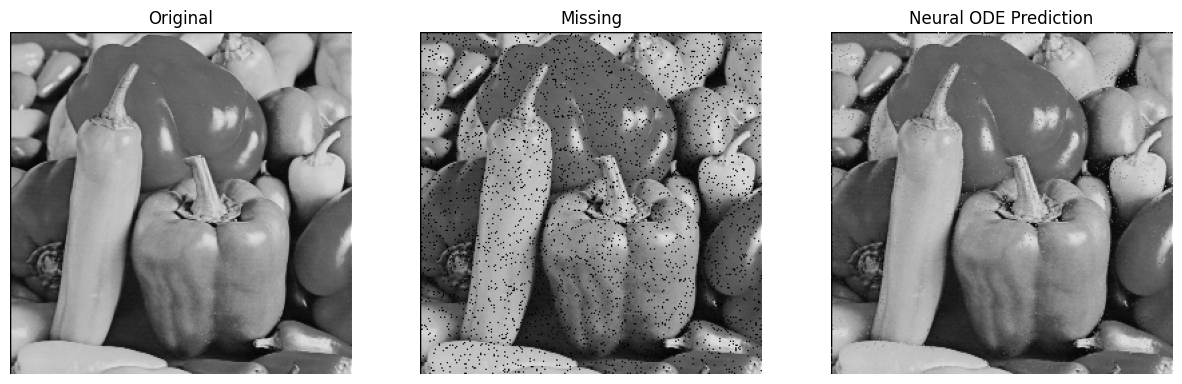

In [ ]:
# ============================================
# Neural ODE 画像欠損補間
# 「既知画素は保持し、欠損画素だけ補間」
# ============================================

import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

from torchdiffeq import odeint

# ============================================
# 画像読み込み
# ============================================

# 白黒画像として読み込み
img = Image.open("Images/Peppers.png").convert("L")
#.convert("L")で開いた画像を別の色の形式に変換する命令。"L"はグレースケールを意味する。

# 解像度
img = img.resize((256,256))

# numpy化。imgの画像の各画素値0~256の値に変換して配列にする。
# .astype(np.float32)で便宜上データの種類を32ビット浮動小数点数に変換（0→0.0）
img_array = np.array(img).astype(np.float32)

# 画素値（色の数値：0~255の値）を0〜1正規化
img_array = img_array / 255.0

# ============================================
# 座標作成
# ============================================

#img_array.shape（.shapeはnumpyの属性）でimg_arrayが縦横何マスなのか取得できる
height, width = img_array.shape

# 座標正規化（重要）
# -1~1までwidthの数だけ分割する処理。これでどんな画像のサイズでも中心が０，端が1、－1となり、統一して計算できる
x = np.linspace(-1,1,width)
y = np.linspace(-1,1,height)

X, Y = np.meshgrid(x, y)

# ============================================
# 欠損作成
# ============================================

# np.ones() は、指定されたサイズで「中身がすべて 1 のデータ」を作る関数
# dtype=boolで数字の１ではなくBoolean型（True/False）に変換。１の場合はTrue
# 後の欠損部分をくりぬく処理で便利
mask = np.ones(img_array.shape, dtype=bool)


# 欠損させるピクセル(座標ランダム版)

np.random.seed(42)

# 全画素の５％のピクセル数
num_missing = int(height * width * 0.05)

indices = np.random.choice(
    height * width,
    num_missing,
    replace=False #「重複無し」の意味。一度選んだピクセルの位置は二度とえらばない→正確にかぶりなく5％分の場所を確保できる
)

missing_points = [
    (idx // width, idx % width)
    for idx in indices
]
"""
#ブロック欠損版
missing_points = []

for i in range(100,156):
    for j in range(100,156):
        missing_points.append((i,j))
# 欠損させるピクセル(座標指定版)

missing_points = [

    (20,20),
    (20,21),
    (20,22),

    (21,20),
    (21,21),
    (21,22),

    (22,20),
    (22,21),
    (22,22),

    (40,40),
    (41,41),
    (42,42)

]
"""
# 欠損化
for i,j in missing_points:

    mask[i,j] = False #欠損にしたい座標(i,j)だけをFalseにする

# 欠損画像
img_missing = img_array.copy() #元データを書き換えないためにコピーを作る

img_missing[~mask] = np.nan #欠損指定した座標だけNaNに置き換える

# ============================================
# 学習データ作成
# ============================================

coords = np.stack(
    [X.flatten(), Y.flatten()],
    axis=1
)

targets = img_array.flatten()

mask_flat = mask.flatten()

# 観測点のみ学習
coords_train = coords[mask_flat]

targets_train = targets[mask_flat]

# Tensor化
coords_tensor = torch.tensor(
    coords_train,
    dtype=torch.float32
)

targets_tensor = torch.tensor(
    targets_train,
    dtype=torch.float32
).view(-1,1)

# ============================================
# ODE Function
# ============================================

class ODEFunc(nn.Module):

    def __init__(self):

        super().__init__()

        self.net = nn.Sequential(

            nn.Linear(2,128),
            nn.Tanh(),

            nn.Linear(128,128),
            nn.Tanh(),

            nn.Linear(128,128),
            nn.Tanh(),

            nn.Linear(128,2)

        )

    def forward(self, t, h):

        return self.net(h)

# ============================================
# Neural ODE
# ============================================

class NeuralODEModel(nn.Module):

    def __init__(self):

        super().__init__()

        self.odefunc = ODEFunc()

        self.output_layer = nn.Linear(2,1)

    def forward(self, x_input):

        h0 = x_input

        t = torch.tensor([0,1]).float()

        out = odeint(
            self.odefunc,
            h0,
            t,
            method='rk4'
        )

        h_final = out[-1]

        z_pred = self.output_layer(h_final)

        return z_pred

# ============================================
# モデル
# ============================================

model = NeuralODEModel()

criterion = nn.MSELoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

# ============================================
# 学習
# ============================================

epochs = 3000

for epoch in range(epochs):

    optimizer.zero_grad()

    pred = model(coords_tensor)

    loss = criterion(
        pred,
        targets_tensor
    )

    loss.backward()

    optimizer.step()

    if epoch % 300 == 0:

        print(
            f"Epoch {epoch} "
            f"Loss {loss.item()}"
        )

# ============================================
# 全画素予測
# ============================================

all_coords_tensor = torch.tensor(
    coords,
    dtype=torch.float32
)

with torch.no_grad():

    img_pred = model(
        all_coords_tensor
    ).numpy()

img_pred = img_pred.reshape(
    height,
    width
)

# ============================================
# 欠損部分だけ補間
# ============================================

# 既知画素はそのまま
final_img = img_missing.copy()

# 欠損部分だけNeural ODE予測値を代入
final_img[~mask] = img_pred[~mask]

# ============================================
# 欠損点精度表示
# ============================================

print("\n===== 欠損点予測 =====\n")

missing_y, missing_x = np.where(~mask)

for idx in range(len(missing_x)):

    x_val = missing_x[idx]
    y_val = missing_y[idx]

    pred_val = final_img[y_val, x_val]

    true_val = img_array[y_val, x_val]

    error = abs(pred_val - true_val)

    print(
        f"({x_val},{y_val}) "
        f"予測={pred_val:.4f} "
        f"真値={true_val:.4f} "
        f"誤差={error:.4f}"
    )

# ============================================
# 欠損点MSE
# ============================================

missing_mse = np.mean(

    (
        img_array[~mask]
        -
        final_img[~mask]

    )**2
)

print("\n==============================")
print("Missing MSE :", missing_mse)
print("==============================")

# ============================================
# 可視化
# ============================================

fig, ax = plt.subplots(1,3, figsize=(15,5))

# 元画像
ax[0].imshow(
    img_array,
    cmap='gray'
)

ax[0].set_title("Original")

# 欠損画像
ax[1].imshow(
    np.nan_to_num(img_missing, nan=0),
    cmap='gray'
)

ax[1].set_title("Missing")

# 補間結果
ax[2].imshow(
    final_img,
    cmap='gray'
)

ax[2].set_title("Neural ODE Prediction")

# 軸OFF
for i in range(3):

    ax[i].axis("off")

plt.show()